# Sales Prediction - Data Exploration & Preprocessing
*Note: Notebook được thiết kế cho Hồi quy (Regression) Dự đoán Doanh thu theo ngày (One-step ahead).*

## Bước 0: Import Libraries
Khởi tạo toàn bộ các thư viện cần thiết cho việc xử lý dữ liệu, trực quan hóa và mô hình Machine Learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

# Preprocessing & Metrics
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Models: Linear Regression (Baseline), KNN, Decision Tree, Random Forest, SVR
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

# Thiết lập style cho biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print(" Đã tải thành công toàn bộ thư viện cần thiết!")


 Đã tải thành công toàn bộ thư viện cần thiết!


## Bước 1: Load Data
Đọc tập dữ liệu `online_retail_II.xlsx` bao gồm tất cả các sheet (2009-2010 và 2010-2011).

In [2]:
# Đọc dữ liệu từ cả hai sheet của file Excel (2009-2010 và 2010-2011)
print("Đang đọc dữ liệu... (sẽ mất khoảng 1-2 phút)")
df_dict = pd.read_excel('online_retail_II.xlsx', sheet_name=None)
df = pd.concat(df_dict.values(), ignore_index=True)

# Khử trùng lặp giao thoa giữa 2 sheet (22,523 dòng từ 01/12/2010 đến 09/12/2010)
init_rows = len(df)
df = df.drop_duplicates()
print(f"Tổng số dòng sau khi đọc và loại bỏ dòng trùng lặp: {len(df):,} (đã khử {init_rows - len(df):,} dòng trùng lặp)")
display(df.head())


Đang đọc dữ liệu... (sẽ mất khoảng 1-2 phút)
Tổng số dòng sau khi đọc và loại bỏ dòng trùng lặp: 1,033,036 (đã khử 34,335 dòng trùng lặp)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## Bước 2: Sanity Check
### a. Kiểm tra kiểu dữ liệu & Giá trị thiếu (Missing Values)

In [3]:
print("--- Data Types ---")
print(df.dtypes)
print("\n--- Missing Values ---")
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
display(pd.DataFrame({'Missing Count': missing_data, 'Missing %': missing_percent}))


--- Data Types ---
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

--- Missing Values ---


,Missing Count,Missing %
Invoice,0,0.000000
StockCode,0,0.000000
Description,4275,0.413829
Quantity,0,0.000000
InvoiceDate,0,0.000000
Price,0,0.000000
Customer ID,235151,22.763098
Country,0,0.000000


### b. Kiểm tra Phân phối & Outliers cơ bản
Nhận xét: Sẽ thấy `Quantity` có giá trị âm rất sâu (trả hàng) và `Price` có giá trị 0 hoặc âm.

,Quantity,InvoiceDate,Price,Customer ID
count,1.033036e+06,1033036,1.033036e+06,797885.000000
mean,1.007688e+01,2011-01-03 14:30:35.429549824,4.613980e+00,15313.062777
min,-8.099500e+04,2009-12-01 07:45:00,-5.359436e+04,12346.000000
25%,1.000000e+00,2010-07-05 11:38:00,1.250000e+00,13964.000000
50%,3.000000e+00,2010-12-09 13:34:00,2.100000e+00,15228.000000
75%,1.000000e+01,2011-07-27 13:17:00,4.150000e+00,16788.000000
max,8.099500e+04,2011-12-09 12:50:00,3.897000e+04,18287.000000
std,1.751976e+02,NaN,1.223975e+02,1696.466663


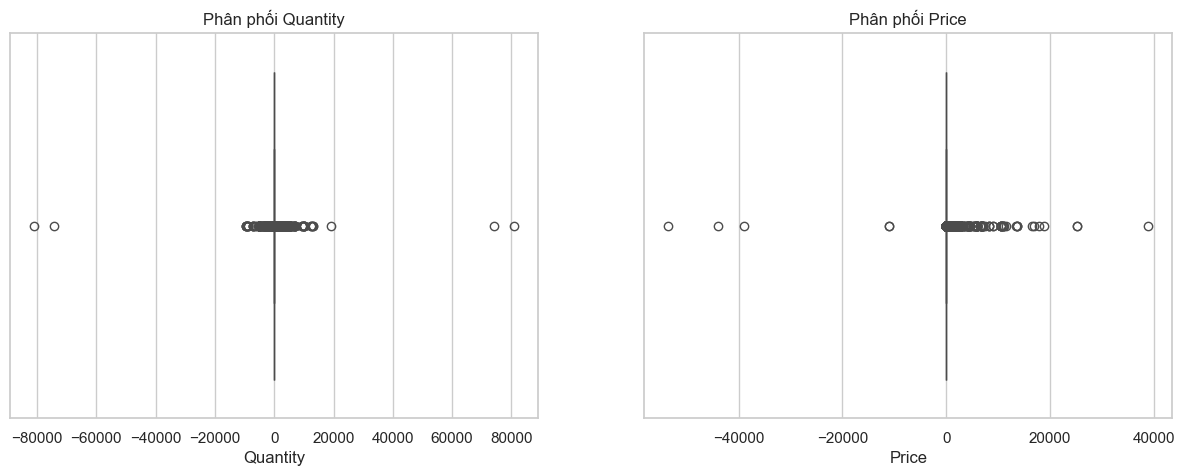

In [4]:
display(df.describe())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(x=df['Quantity'], ax=axes[0]).set_title('Phân phối Quantity')
sns.boxplot(x=df['Price'], ax=axes[1]).set_title('Phân phối Price')
plt.show()


## Bước 3: Exploratory Data Analysis (EDA)
Khám phá các Insight đặc biệt từ dữ liệu.

### 3.1 Giao dịch theo Ngày trong tuần (Day of Week)
**Nhận xét:** Nhìn biểu đồ bạn sẽ thấy Thứ 7 gần như không có / hoặc hoàn toàn trống vắng các giao dịch.

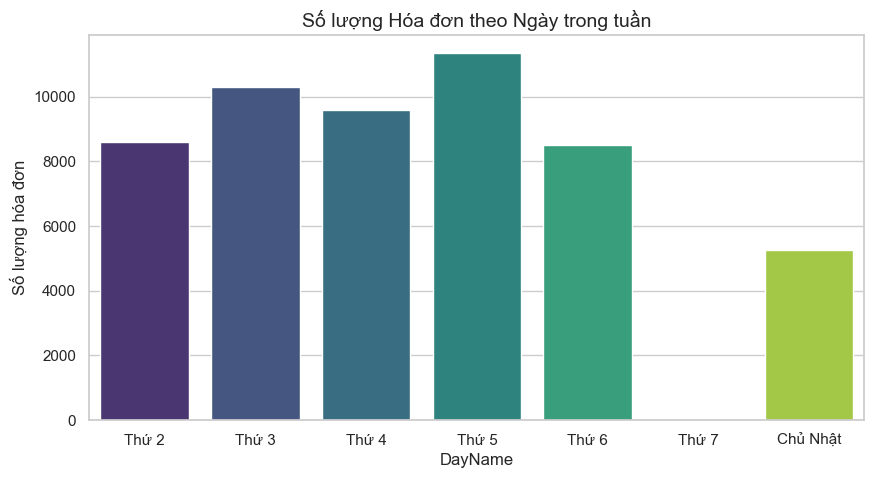

In [5]:
df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek
day_names = {0: 'Thứ 2', 1: 'Thứ 3', 2: 'Thứ 4', 3: 'Thứ 5', 4: 'Thứ 6', 5: 'Thứ 7', 6: 'Chủ Nhật'}
df['DayName'] = df['DayOfWeek'].map(day_names)

transactions_by_day = df.groupby('DayName')['Invoice'].nunique().reindex(day_names.values())

plt.figure(figsize=(10, 5))
sns.barplot(x=transactions_by_day.index, y=transactions_by_day.values, palette='viridis')
plt.title('Số lượng Hóa đơn theo Ngày trong tuần', fontsize=14)
plt.ylabel('Số lượng hóa đơn')
plt.show()


### 3.2 Phân tích Đơn hàng Hủy / Hoàn trả
**Nhận xét:** Hóa đơn bắt đầu bằng 'C' và `Quantity < 0` là đặc trưng của các đơn bị trả/hủy.

In [6]:
df['Is_Cancelled'] = df['Invoice'].astype(str).str.startswith('C')
cancel_rate = df['Is_Cancelled'].mean() * 100
print(f"Tỷ lệ dòng dữ liệu là đơn hủy/trả hàng: {cancel_rate:.2f}%")
display(df[df['Is_Cancelled']].head())


Tỷ lệ dòng dữ liệu là đơn hủy/trả hàng: 1.85%


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,DayOfWeek,DayName,Is_Cancelled
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,1,Thứ 3,True
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia,1,Thứ 3,True
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia,1,Thứ 3,True
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia,1,Thứ 3,True
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,1,Thứ 3,True


### 3.3 Tập trung Địa lý (Country)
**Nhận xét:** Một đặc trưng cực kỳ rõ nét của bộ dataset này là thị trường tập trung vào United Kingdom.

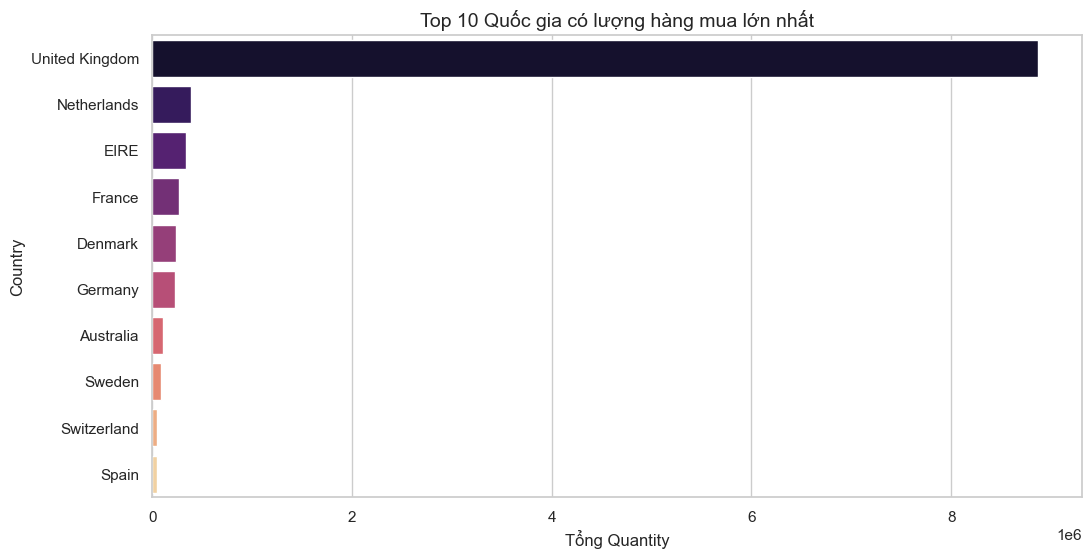

In [7]:
country_sales = df[~df['Is_Cancelled']].groupby('Country')['Quantity'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=country_sales.head(10).values, y=country_sales.head(10).index, palette='magma')
plt.title('Top 10 Quốc gia có lượng hàng mua lớn nhất', fontsize=14)
plt.xlabel('Tổng Quantity')
plt.show()


### 3.4 Xu hướng theo Thời gian (Seasonality)
**Nhận xét:** Doanh thu tăng vọt ở quý 4 hằng năm (hiệu ứng mùa lễ hội cuối năm).

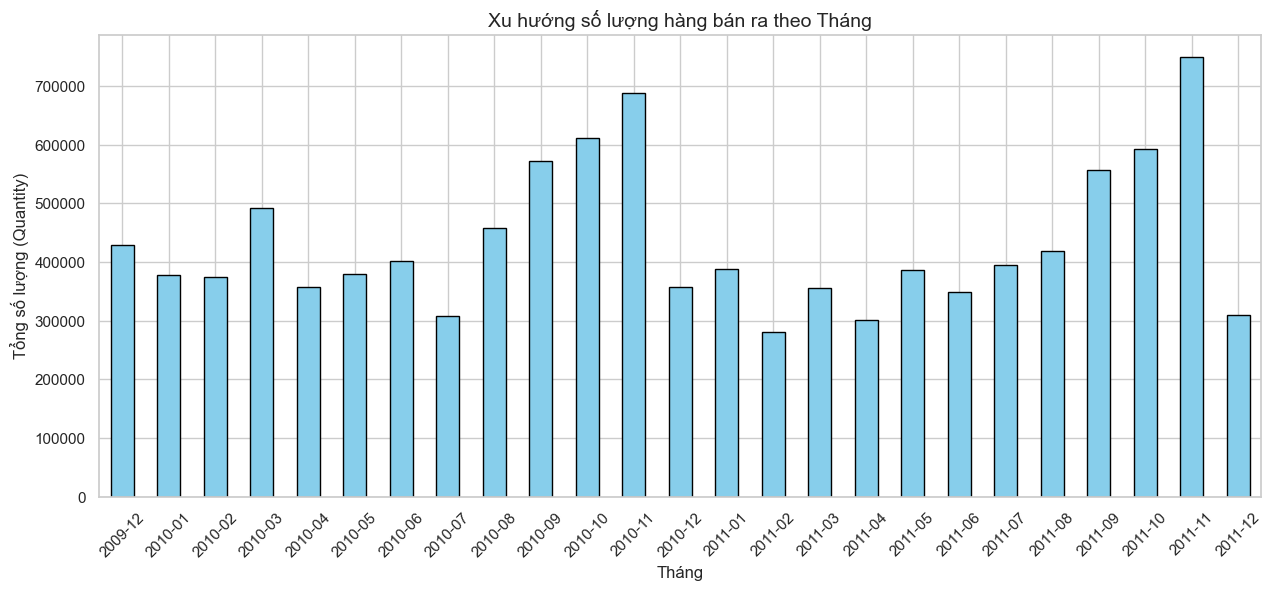

In [8]:
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
sales_trend = df[~df['Is_Cancelled']].groupby('YearMonth')['Quantity'].sum()

plt.figure(figsize=(15, 6))
sales_trend.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Xu hướng số lượng hàng bán ra theo Tháng', fontsize=14)
plt.xlabel('Tháng')
plt.ylabel('Tổng số lượng (Quantity)')
plt.xticks(rotation=45)
plt.show()


---
## Bước 4: Data Cleaning, Xử lý Bất thường & Chuẩn hóa Chuỗi thời gian 

### ️ Các cải tiến cốt lõi đã được nâng cấp:
1. **Lọc sạch dữ liệu giao dịch**:
  - Loại bỏ các dòng hủy/hoàn hàng (`Is_Cancelled == True` hoặc `Quantity <= 0`).
  - Loại bỏ đơn giá không hợp lệ (`Price <= 0`).
  - Loại bỏ các **mã cước phí vận chuyển và dịch vụ kế toán phi sản phẩm**: `POST` (bưu cước), `DOT` (cước dotcom), `M` (manual adjustment), `BANK CHARGES` (phí ngân hàng), `CRUK`, `AMAZONFEE`, `B`, `S`, `ADJUST`, `PADS`.
2. **Tính Doanh thu từng dòng**: $\text{Revenue} = \text{Quantity} \times \text{Price}$.
3. **Tổng hợp theo ngày có Reindex liên tục (Daily Reindex)**:
  - Dùng `pd.date_range` tạo đầy đủ 100% các ngày liên tục từ đầu đến cuối và điền `0` cho các ngày cửa hàng nghỉ bán (như Thứ Bảy).
  - *Ý nghĩa sống còn*: Đảm bảo chuỗi ngày không bị đứt đoạn, giúp các độ trễ **`Lag 1`** (ngày hôm qua) và **`Lag 7`** (cùng thứ tuần trước) phản ánh đúng khoảng cách thời gian thực tế!
4. **Biến đổi `Log1p` Transform**:
  - Doanh số bán lẻ bị lệch phải nặng (Right-skewed) do có những ngày bán sỉ đột biến. Việc lấy `np.log1p(Revenue)` giúp đưa phân phối về dạng quả chuông chuẩn (Normal Distribution), giúp các mô hình hồi quy học ổn định hơn rất nhiều.


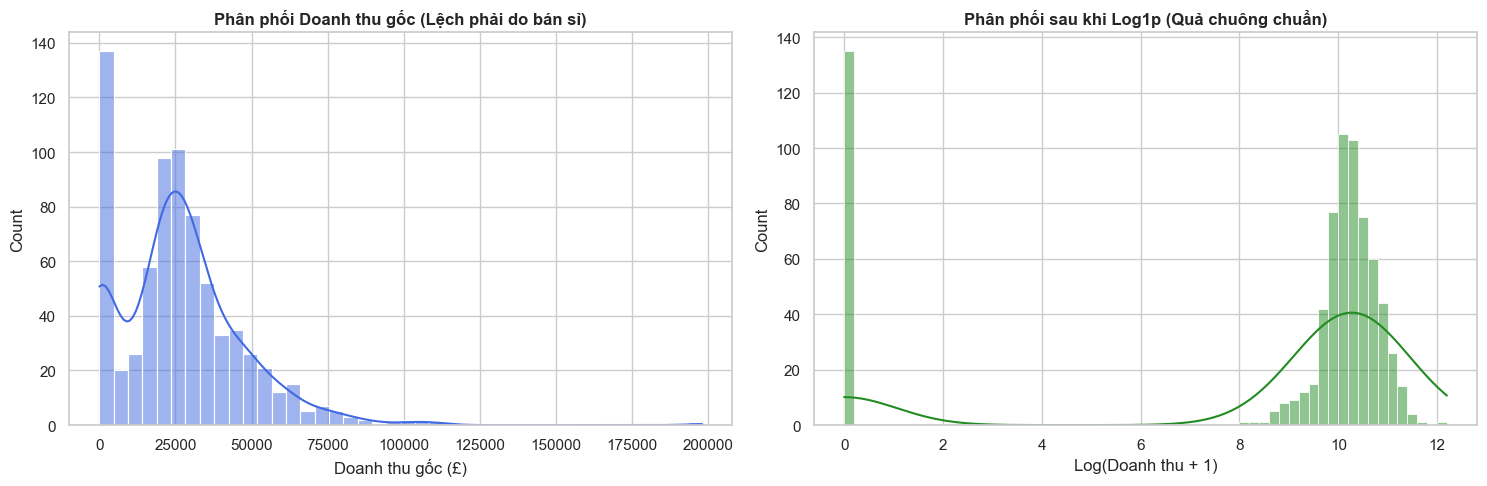

Tổng số ngày trong chuỗi thời gian liên tục: 739 ngày


,Revenue,Log_Revenue
Date,,
2009-12-01,52438.61,10.867418
2009-12-02,61873.10,11.032857
2009-12-03,73109.78,11.199731
2009-12-04,39349.21,10.580257
2009-12-05,9803.05,9.190551


In [9]:
# 1. Điền giá trị khuyết cho cột phân loại
df['Customer ID'].fillna('Guest', inplace=True)
df['Description'].fillna('Unknown', inplace=True)

# 2. Danh sách các mã dịch vụ / cước phí / nợ xấu phi sản phẩm cần loại bỏ
service_codes = ['POST', 'DOT', 'M', 'D', 'BANK CHARGES', 'CRUK', 'AMAZONFEE', 'B', 'S', 'ADJUST', 'PADS']

# Lọc các giao dịch bán hàng hợp lệ
df_clean = df[
  (~df['Is_Cancelled']) & 
  (~df['Invoice'].astype(str).str.startswith('A')) & 
  (df['Quantity'] > 0) & 
  (df['Price'] > 0) & 
  (~df['StockCode'].astype(str).isin(service_codes))
].copy()

# Tính Doanh thu từng dòng giao dịch
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['Price']
df_clean['Date'] = pd.to_datetime(df_clean['InvoiceDate'].dt.date)

# 3. Gom nhóm theo Ngày (Daily Sales)
daily_sales = df_clean.groupby('Date')['Revenue'].sum().reset_index()

# 4. TẠO DẢI NGÀY LIÊN TỤC VÀ ĐIỀN 0 CHO THỨ BẢY NGHỈ BÁN
full_dates = pd.date_range(start=daily_sales['Date'].min(), end=daily_sales['Date'].max(), freq='D')
daily_sales = daily_sales.set_index('Date').reindex(full_dates, fill_value=0).reset_index()
daily_sales.rename(columns={'index': 'Date'}, inplace=True)

# 5. Biến đổi Log1p cho Doanh thu
daily_sales['Log_Revenue'] = np.log1p(daily_sales['Revenue'])

# Trực quan hoá hiệu quả của phép biến đổi Log1p
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(daily_sales['Revenue'], kde=True, ax=axes[0], color='royalblue').set_title('Phân phối Doanh thu gốc (Lệch phải do bán sỉ)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Doanh thu gốc (£)')

sns.histplot(daily_sales['Log_Revenue'], kde=True, ax=axes[1], color='forestgreen').set_title('Phân phối sau khi Log1p (Quả chuông chuẩn)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Log(Doanh thu + 1)')
plt.tight_layout()
plt.show()

daily_sales.set_index('Date', inplace=True)
print(f"Tổng số ngày trong chuỗi thời gian liên tục: {len(daily_sales)} ngày")
display(daily_sales.head())


---
## Bước 5: Bộ Feature  (Feature Engineering) & Phân chia Thời gian 

### Ý nghĩa của từng Đặc trưng (Features):
1. **`Day_of_Week`**: Thứ mấy trong tuần (0: Thứ Hai $\to$ 6: Chủ Nhật).
2. **`Month`**: Tháng trong năm (1 $\to$ 12) $\to$ Nắm bắt tính mùa vụ hàng năm.
3. **`Is_Weekend`**: Cờ nhận diện cuối tuần (gồm cả Thứ Bảy = 5 và Chủ Nhật = 6) $\to$ Tách biệt ngày làm việc và ngày nghỉ.
4. **`Promo_Season`**: Cờ mùa cao điểm mua sắm Quý 4 (tháng 9, 10, 11) trước lễ Giáng sinh.
5. **`Lag_1`**: Doanh số ngày hôm qua $\to$ Nắm bắt quán tính bán hàng ngắn nhất.
6. **`Lag_7`**: Doanh số cùng thứ này tuần trước $\to$ Nắm bắt chu kỳ tuần (Weekly Seasonality - cực kỳ quan trọng!).
7. **`Rolling_Mean_7`**: Trung bình động 7 ngày gần nhất $\to$ Thể hiện xu hướng tăng/giảm chung của tuần qua.
8. **`Rolling_Std_7`**: Độ biến động 7 ngày gần nhất $\to$ Đo lường mức độ trồi sụt của sức mua.

### ️ Phân chia Train/Test theo Thời gian:
- **Nguyên tắc sống còn**: `shuffle = False`. Cắt theo mốc thời gian (Quá khứ làm Train, Tương lai làm Test) để tránh hiện tượng rò rỉ dữ liệu (Data Leakage).
- Mốc cắt: `2011-05-01` (hoặc phân chia 80:20).


In [10]:
# 1. Tạo các biến Lịch & Mùa vụ
daily_sales['Day_of_Week'] = daily_sales.index.dayofweek
daily_sales['Month'] = daily_sales.index.month
daily_sales['Is_Weekend'] = daily_sales['Day_of_Week'].isin([5, 6]).astype(int)# Bao gồm cả Thứ 7 (5) và CN (6)
daily_sales['Promo_Season'] = daily_sales['Month'].isin([9, 10, 11]).astype(int)

# 2. Tạo các biến Trễ (Lag) và Thống kê trượt (Rolling) trên Log_Revenue
daily_sales['Lag_1'] = daily_sales['Log_Revenue'].shift(1)
daily_sales['Lag_7'] = daily_sales['Log_Revenue'].shift(7)
daily_sales['Rolling_Mean_7'] = daily_sales['Lag_1'].rolling(window=7).mean()
daily_sales['Rolling_Std_7'] = daily_sales['Lag_1'].rolling(window=7).std()

# 3. Loại bỏ các dòng đầu tiên bị NaN do trượt độ trễ 7 ngày
daily_sales_final = daily_sales.dropna().copy()
print(f"Số lượng mẫu dữ liệu hoàn chỉnh sau khi xử lý Lag: {len(daily_sales_final)} ngày")

# 4. Phân chia Train - Test theo mốc thời gian (KHÔNG SHUFFLE)
CUTOFF_DATE = '2011-05-01'
train_data = daily_sales_final[daily_sales_final.index < CUTOFF_DATE]
test_data = daily_sales_final[daily_sales_final.index >= CUTOFF_DATE]

features = ['Day_of_Week', 'Month', 'Is_Weekend', 'Promo_Season', 'Lag_1', 'Lag_7', 'Rolling_Mean_7', 'Rolling_Std_7']
X_train, y_train = train_data[features], train_data['Log_Revenue']
X_test, y_test = test_data[features], test_data['Log_Revenue']

# 5. Chuẩn hoá dữ liệu (StandardScaler) cho các mô hình nhạy cảm khoảng cách
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=features, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=features, index=X_test.index)

print(f"- Tập Train: {len(X_train)} ngày (từ {train_data.index.min().strftime('%d/%m/%Y')} đến {train_data.index.max().strftime('%d/%m/%Y')})")
print(f"- Tập Test: {len(X_test)} ngày (từ {test_data.index.min().strftime('%d/%m/%Y')} đến {test_data.index.max().strftime('%d/%m/%Y')})")
display(daily_sales_final[features + ['Log_Revenue']].head())


Số lượng mẫu dữ liệu hoàn chỉnh sau khi xử lý Lag: 732 ngày
- Tập Train: 509 ngày (từ 08/12/2009 đến 30/04/2011)
- Tập Test:  223 ngày (từ 01/05/2011 đến 09/12/2011)


,Day_of_Week,Month,Is_Weekend,Promo_Season,Lag_1,Lag_7,Rolling_Mean_7,Rolling_Std_7,Log_Revenue
Date,,,,,,,,,
2009-12-08,1,12,0,0,10.670314,10.867418,10.519826,0.685297,10.794372
2009-12-09,2,12,0,0,10.794372,11.032857,10.509391,0.679655,10.568012
2009-12-10,3,12,0,0,10.568012,11.199731,10.442985,0.641630,10.650445
2009-12-11,4,12,0,0,10.650445,10.580257,10.364515,0.562347,10.582761
2009-12-12,5,12,1,0,10.582761,9.190551,10.364873,0.562508,0.000000


Huấn luyện 5 mô hình theo đúng khung sườn giáo trình:
  - Linear Regression (Baseline Model): Mô hình hồi quy tuyến tính làm mức cơ sở để so sánh và phân tích hệ số $\beta$ (Coefficients).
  - Decision Tree Regressor: Phân nhánh phi tuyến.
  - Random Forest Regressor: Kết hợp 100 cây quyết định để giảm phương sai sai số.
  - KNN Regressor & Support Vector Regressor (SVR):
  - KNN Regressor (K=5): Tìm các ngày có pattern tương tự trong quá khứ.
  - SVR (RBF Kernel): Tối ưu hoá biên dung sai phi tuyến.

 **Quy trình Đánh giá**: Mô hình học và dự đoán trên thang log (`y_pred_log`), sau đó dùng **`np.expm1`** khôi phục về số tiền **Bảng Anh (£ GBP)** thực tế để tính $R^2$, MAE và RMSE.


In [11]:
# Định nghĩa 5 mô hình (Linear Regression làm baseline, Tree/Forest làm chủ lực, KNN & SVR đối sánh)
models_config = {
  'Linear Regression': (LinearRegression(), True),
  'KNN Regressor': (KNeighborsRegressor(n_neighbors=5, weights='distance'), True),
  'Decision Tree': (DecisionTreeRegressor(max_depth=5, min_samples_split=5, random_state=42), False),
  'Random Forest': (RandomForestRegressor(n_estimators=100, max_depth=6, min_samples_split=5, random_state=42, n_jobs=-1), False),
  'SVR': (SVR(kernel='rbf', C=10.0, epsilon=0.1), True)
}

results = []
predictions_dict = {}
trained_models = {}

# Giá trị thực tế trên đơn vị tiền Bảng Anh (£ GBP)
y_train_actual = np.expm1(y_train)
y_test_actual = np.expm1(y_test)

for name, (model, use_scaled) in models_config.items():
  t0 = time.time()
  xtr = X_train_scaled if use_scaled else X_train
  xte = X_test_scaled if use_scaled else X_test
  
 # Huấn luyện mô hình
  model.fit(xtr, y_train)
  fit_time = time.time() - t0
  trained_models[name] = model
  
 # Dự đoán trên tập Train và tập Test (thang log)
  y_pred_tr_log = model.predict(xtr)
  y_pred_te_log = model.predict(xte)
  
 # Khôi phục về thang tiền Bảng Anh (£) thực tế
  y_pred_tr_actual = np.expm1(y_pred_tr_log)
  y_pred_te_actual = np.expm1(y_pred_te_log)
  predictions_dict[name] = y_pred_te_actual
  
 # Tính toán các chỉ số đánh giá theo đề cương
  train_r2 = r2_score(y_train_actual, y_pred_tr_actual)
  test_r2 = r2_score(y_test_actual, y_pred_te_actual)
  mae = mean_absolute_error(y_test_actual, y_pred_te_actual)
  rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_te_actual))
  
  results.append({
    'Model': name,
    'Train R²': round(train_r2, 4),
    'Test R²': round(test_r2, 4),
    'MAE (£)': round(mae, 2),
    'RMSE (£)': round(rmse, 2),
    'Fit Time (s)': round(fit_time, 3)
  })

df_results = pd.DataFrame(results).sort_values(by='MAE (£)').reset_index(drop=True)
print(" BẢNG TỔNG HỢP HIỆU NĂNG 5 MÔ HÌNH HỒI QUY (XẾP THEO MAE THẤP NHẤT)")
display(df_results)


 BẢNG TỔNG HỢP HIỆU NĂNG 5 MÔ HÌNH HỒI QUY (XẾP THEO MAE THẤP NHẤT)


,Model,Train R²,Test R²,MAE (£),RMSE (£),Fit Time (s)
0,SVR,0.6796,0.5236,9558.58,16818.54,0.011
1,KNN Regressor,0.9990,0.4769,10407.94,17624.31,0.002
2,Random Forest,0.5913,0.3777,11290.19,19222.78,0.095
3,Decision Tree,0.4180,0.1304,13862.01,22723.92,0.002
4,Linear Regression,-0.5666,-0.2235,18174.63,26953.55,0.002


---
## Bước 7: Trực quan hóa So sánh Hiệu năng & Chuỗi thời gian (Model Evaluation)

Vẽ đồ thị cột so sánh trực quan $R^2$, MAE, RMSE và đồ thị chuỗi thời gian so sánh giữa Thực tế vs Dự báo.


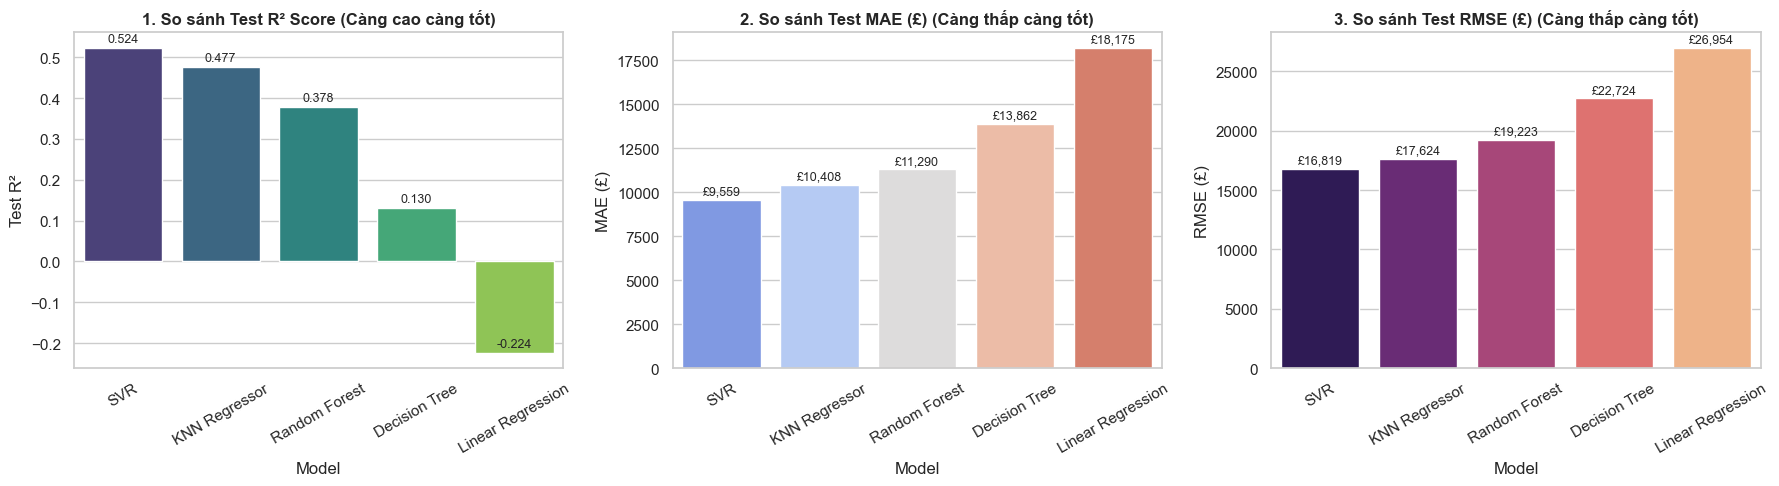

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. So sánh Test R² Score
sns.barplot(data=df_results, x='Model', y='Test R²', ax=axes[0], palette='viridis')
axes[0].set_title('1. So sánh Test R² Score (Càng cao càng tốt)', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)
for p in axes[0].patches:
  axes[0].annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width() / 2., p.get_height()),
           ha='center', va='bottom', fontsize=9, xytext=(0, 2), textcoords='offset points')

# 2. So sánh MAE (£)
sns.barplot(data=df_results, x='Model', y='MAE (£)', ax=axes[1], palette='coolwarm')
axes[1].set_title('2. So sánh Test MAE (£) (Càng thấp càng tốt)', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)
for p in axes[1].patches:
  axes[1].annotate(f"£{p.get_height():,.0f}", (p.get_x() + p.get_width() / 2., p.get_height()),
           ha='center', va='bottom', fontsize=9, xytext=(0, 2), textcoords='offset points')

# 3. So sánh RMSE (£)
sns.barplot(data=df_results, x='Model', y='RMSE (£)', ax=axes[2], palette='magma')
axes[2].set_title('3. So sánh Test RMSE (£) (Càng thấp càng tốt)', fontsize=12, fontweight='bold')
axes[2].tick_params(axis='x', rotation=30)
for p in axes[2].patches:
  axes[2].annotate(f"£{p.get_height():,.0f}", (p.get_x() + p.get_width() / 2., p.get_height()),
           ha='center', va='bottom', fontsize=9, xytext=(0, 2), textcoords='offset points')

plt.tight_layout()
plt.show()


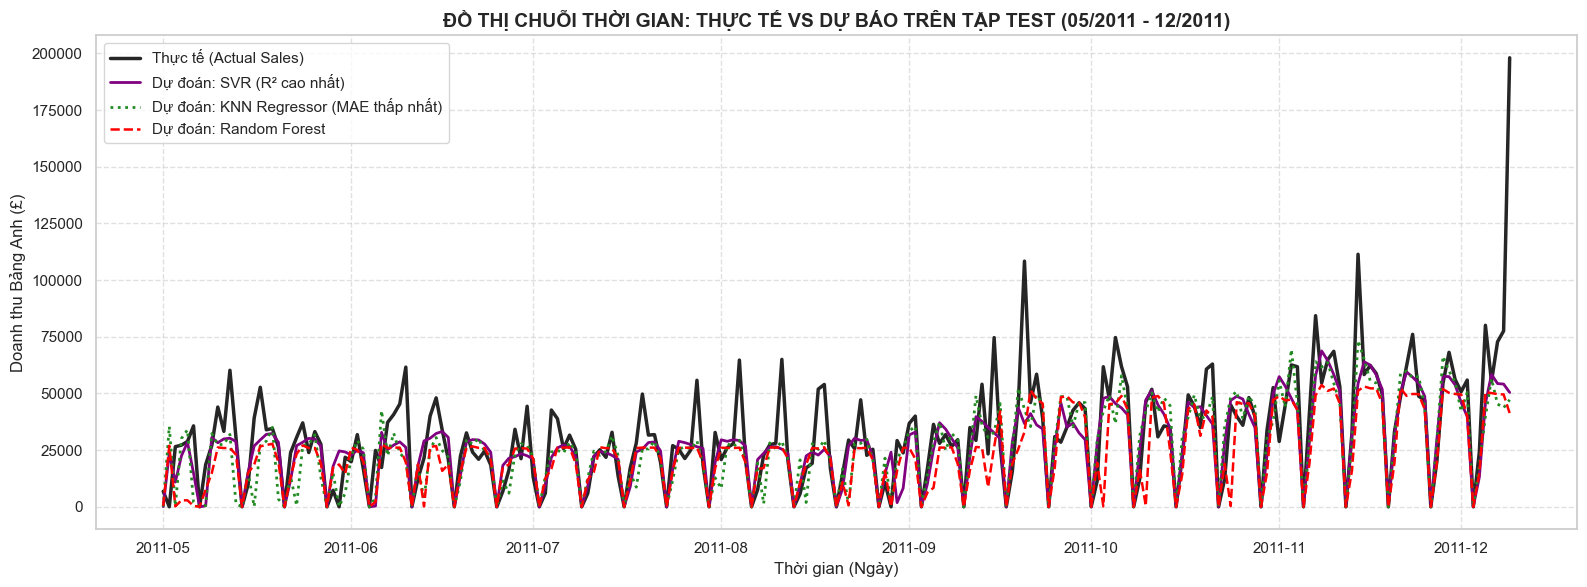

In [13]:
# Đồ thị Chuỗi thời gian: Thực tế vs Dự báo trên tập Test
plt.figure(figsize=(16, 6))

plt.plot(test_data.index, y_test_actual, label='Thực tế (Actual Sales)', color='black', linewidth=2.5, alpha=0.85)
plt.plot(test_data.index, predictions_dict['SVR'], label='Dự đoán: SVR (R² cao nhất)', color='purple', linestyle='-', linewidth=2)
plt.plot(test_data.index, predictions_dict['KNN Regressor'], label='Dự đoán: KNN Regressor (MAE thấp nhất)', color='forestgreen', linestyle=':', linewidth=2)
plt.plot(test_data.index, predictions_dict['Random Forest'], label='Dự đoán: Random Forest', color='red', linestyle='--', linewidth=1.8)

plt.title('ĐỒ THỊ CHUỖI THỜI GIAN: THỰC TẾ VS DỰ BÁO TRÊN TẬP TEST (05/2011 - 12/2011)', fontsize=14, fontweight='bold')
plt.xlabel('Thời gian (Ngày)', fontsize=12)
plt.ylabel('Doanh thu Bảng Anh (£)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


---
## Bước 8: Phân tích Tầm quan trọng của Thuộc tính (Feature Importance & Coefficients)

Trả lời yêu cầu của đề tài: **Thuộc tính nào ảnh hưởng lớn nhất đến Doanh số?**
1. **Hệ số hồi quy $\beta$ (Coefficients) của Linear Regression (Baseline)**: Cho biết chiều hướng tác động của từng thuộc tính lên doanh số (dấu dương là làm tăng, dấu âm là làm giảm).
2. **Feature Importance của Random Forest (Mô hình chủ lực)**: Cho biết tỷ lệ đóng góp của từng biến khi phân nhánh cây quyết định.


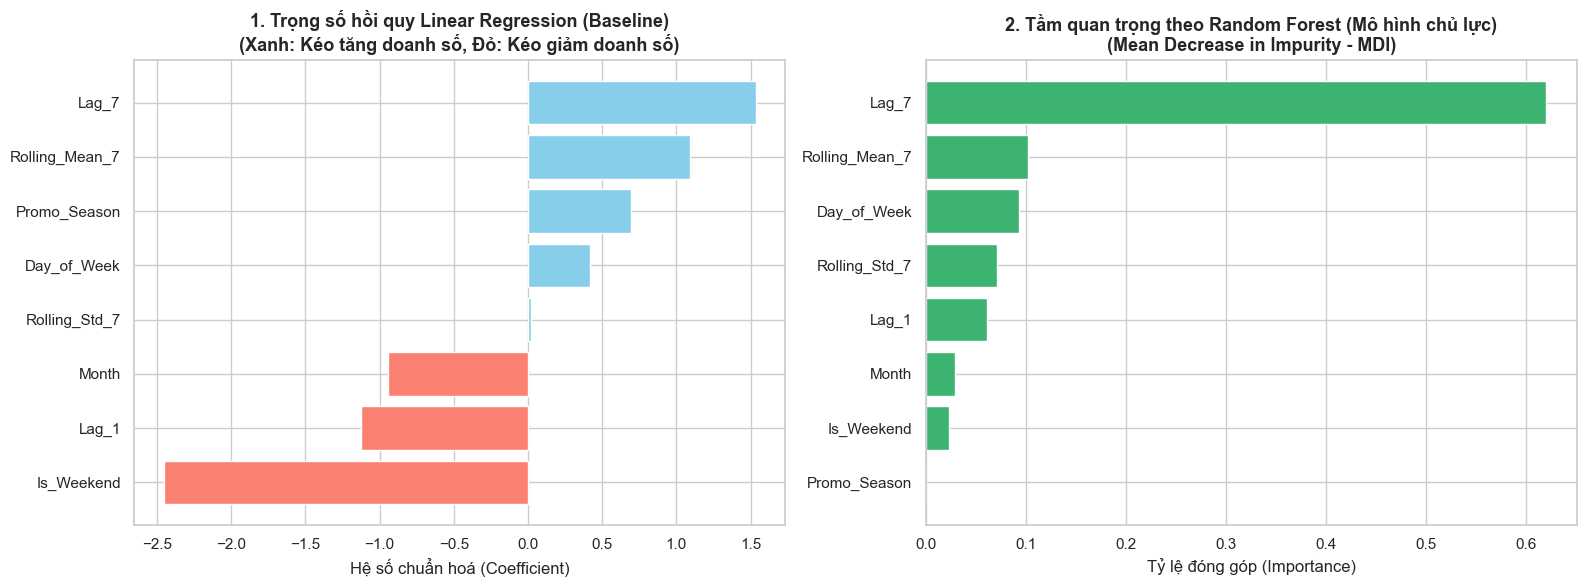

BẢNG TẦM QUAN TRỌNG THEO RANDOM FOREST:


,Feature,Importance
0,Lag_7,0.619744
1,Rolling_Mean_7,0.101913
2,Day_of_Week,0.093326
3,Rolling_Std_7,0.070986
4,Lag_1,0.061335
5,Month,0.028847
6,Is_Weekend,0.023747
7,Promo_Season,0.000103


In [14]:
# 1. Trích xuất Coefficients của Linear Regression (Baseline)
linear_model = trained_models['Linear Regression']
linear_coef_df = pd.DataFrame({
  'Feature': features,
  'Coefficient': linear_model.coef_
}).sort_values(by='Coefficient', ascending=False)

# 2. Trích xuất Feature Importance của Random Forest (Mô hình chủ lực)
rf_model = trained_models['Random Forest']
rf_imp_df = pd.DataFrame({
  'Feature': features,
  'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Đồ thị Linear Regression Coefficients
coef_sorted = linear_coef_df.sort_values(by='Coefficient', ascending=True)
colors_linear = ['salmon' if w < 0 else 'skyblue' for w in coef_sorted['Coefficient']]
axes[0].barh(coef_sorted['Feature'], coef_sorted['Coefficient'], color=colors_linear)
axes[0].set_title('1. Trọng số hồi quy Linear Regression (Baseline)\n(Xanh: Kéo tăng doanh số, Đỏ: Kéo giảm doanh số)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Hệ số chuẩn hoá (Coefficient)')

# Đồ thị Random Forest Importance
rf_sorted = rf_imp_df.sort_values(by='Importance', ascending=True)
axes[1].barh(rf_sorted['Feature'], rf_sorted['Importance'], color='mediumseagreen')
axes[1].set_title('2. Tầm quan trọng theo Random Forest (Mô hình chủ lực)\n(Mean Decrease in Impurity - MDI)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Tỷ lệ đóng góp (Importance)')

plt.tight_layout()
plt.show()

print("BẢNG TẦM QUAN TRỌNG THEO RANDOM FOREST:")
display(rf_imp_df.reset_index(drop=True))
